In [1]:
import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

import xgboost as xgb

warnings.filterwarnings('ignore')

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Imports completed successfully')

Imports completed successfully


In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [3]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# Strip whitespace from column names
df.columns = [c.strip() for c in df.columns]

print("Shape:", df.shape)
display(df.head())

Shape: (130, 65)


,Participant code,Age (years),Gender,Positive history of Parkinson disease in family,Age of disease onset (years),Duration of disease from first symptoms (years),Antidepressant therapy,Antiparkinsonian medication,Antipsychotic medication,Benzodiazepine medication,...,Acceleration of speech timing (-/min2) .1,Duration of pause intervals (ms) .1,Duration of voiced intervals (ms) .1,Gaping in-between voiced Intervals (-/min),Duration of unvoiced stops (ms) .1,Decay of unvoiced fricatives (‰/min) .1,Relative loudness of respiration (dB) .1,Pause intervals per respiration (-) .1,Rate of speech respiration (-/min) .1,Latency of respiratory exchange (ms) .1
0,PD01,58,F,No,56,2,No,No,No,No,...,-2.82,158,318,49.01,22.37,0.588,-19.77,6.0,13.81,127
1,PD02,68,F,No,67,1,No,No,No,No,...,8.20,295,264,40.56,26.88,-0.825,-23.26,4.0,21.77,313
2,PD03,68,M,No,67,1,No,No,No,No,...,4.71,280,317,48.97,22.37,-0.955,-13.29,4.0,22.52,201
3,PD04,75,M,No,73,2,No,No,No,No,...,-9.09,397,800,18.69,49.37,0.791,-25.08,2.0,14.37,151
4,PD05,61,M,Yes,60,0.7,No,No,No,No,...,11.77,206,480,33.54,26.87,0.075,-22.32,5.0,14.61,151


In [4]:
# ── Derive target from participant code prefix ─────────────────────────────
# PD = Parkinson's Disease, RB = REM Behaviour Disorder, HC = Healthy Control
df['label'] = df['Participant  code'].str[:2].map({'PD': 0, 'RB': 1, 'HC': 2})

print('Label distribution:')
print(df['label'].value_counts())

# ── Drop non-feature columns ───────────────────────────────────────────────
DROP_COLS = ['Participant  code', 'label']
X_raw = df.drop(columns=DROP_COLS)
y = df['label']

# ── Encode categoricals ────────────────────────────────────────────────────
CATEGORICAL_COLS = [
    'Gender',
    'Positive  history  of  Parkinson  disease  in  family',
    'Antidepressant  therapy',
    'Antiparkinsonian  medication',
    'Antipsychotic  medication',
    'Benzodiazepine  medication',
]

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col].astype(str).str.strip())

# ── Remaining string columns to numeric ───────────────────────────────────
for col in X_raw.select_dtypes(include='object').columns:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')

X_raw = X_raw.fillna(X_raw.median())

print('Features shape:', X_raw.shape)
print('Dtypes after encoding:')
print(X_raw.dtypes.value_counts())

Label distribution:
label
1    50
2    50
0    30
Name: count, dtype: int64
Features shape: (130, 64)
Dtypes after encoding:
float64    48
int64      16
Name: count, dtype: int64


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print('Train:', X_train.shape)
print('Val:  ', X_val.shape)
print('Test: ', X_test.shape)

Train: (91, 64)
Val:   (19, 64)
Test:  (20, 64)


In [6]:
scaler_xgb = StandardScaler()
X_train_xgb = scaler_xgb.fit_transform(X_train)
X_val_xgb   = scaler_xgb.transform(X_val)
X_test_xgb  = scaler_xgb.transform(X_test)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.5,
    random_state=42,
    tree_method='hist',
    eval_metric='mlogloss',
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_test_xgb)
xgb_acc   = accuracy_score(y_test, xgb_preds)
xgb_f1    = f1_score(y_test, xgb_preds, average='weighted', zero_division=0)

print('XGBoost Test Accuracy:', round(xgb_acc, 4))
print('XGBoost Test F1:      ', round(xgb_f1, 4))
print(classification_report(y_test, xgb_preds, zero_division=0))

XGBoost Test Accuracy: 0.95
XGBoost Test F1:       0.9511
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.88      0.93         8
           2       1.00      1.00      1.00         8

    accuracy                           0.95        20
   macro avg       0.93      0.96      0.94        20
weighted avg       0.96      0.95      0.95        20



In [7]:
scaler_rf = StandardScaler()
X_train_rf = scaler_rf.fit_transform(X_train)
X_val_rf   = scaler_rf.transform(X_val)
X_test_rf  = scaler_rf.transform(X_test)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train)

rf_preds = rf_model.predict(X_test_rf)
rf_acc   = accuracy_score(y_test, rf_preds)
rf_f1    = f1_score(y_test, rf_preds, average='weighted', zero_division=0)

print('OOB Score:                  ', round(rf_model.oob_score_, 4))
print('Random Forest Test Accuracy:', round(rf_acc, 4))
print('Random Forest Test F1:      ', round(rf_f1, 4))
print(classification_report(y_test, rf_preds, zero_division=0))

OOB Score:                   0.9231
Random Forest Test Accuracy: 0.9
Random Forest Test F1:       0.9
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.88      0.88      0.88         8
           2       1.00      1.00      1.00         8

    accuracy                           0.90        20
   macro avg       0.88      0.88      0.88        20
weighted avg       0.90      0.90      0.90        20



In [8]:
class _SubModel:
    """Thin wrapper — inference_rem.py accesses sub_model.scaler and sub_model.model."""
    def __init__(self, model, scaler):
        self.model  = model
        self.scaler = scaler

    def predict(self, X):
        return self.model.predict(self.scaler.transform(X))

    def predict_proba(self, X):
        return self.model.predict_proba(self.scaler.transform(X))


class REMEnsemble:
    """
    Fused ensemble consumed by inference_rem.py.
    Required attributes:
        .feature_names  – list[str]
        .models         – dict[str, _SubModel]
        .fusion_method  – str
    """
    def __init__(self, models, feature_names, fusion_method='voting'):
        self.models        = models
        self.feature_names = feature_names
        self.fusion_method = fusion_method

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        proba_list = [sub.predict_proba(X) for sub in self.models.values()]
        return np.mean(proba_list, axis=0)

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        preds = np.column_stack([sub.predict(X) for sub in self.models.values()])
        return np.apply_along_axis(
            lambda row: np.bincount(row.astype(int)).argmax(),
            axis=1,
            arr=preds
        )


FUSION_METHOD = 'voting'

ensemble = REMEnsemble(
    models={
        'XGBoost':      _SubModel(xgb_model, scaler_xgb),
        'RandomForest': _SubModel(rf_model,  scaler_rf),
    },
    feature_names=list(X_raw.columns),
    fusion_method=FUSION_METHOD,
)

ensemble_preds = ensemble.predict(
    pd.DataFrame(X_test.values, columns=X_raw.columns)
)

ensemble_acc = accuracy_score(y_test, ensemble_preds)
ensemble_f1  = f1_score(
    y_test, ensemble_preds,
    average='weighted',
    zero_division=0
)

print('Ensemble Test Accuracy:', round(ensemble_acc, 4))
print('Ensemble Test F1:      ', round(ensemble_f1, 4))
print(classification_report(y_test, ensemble_preds, zero_division=0))

Ensemble Test Accuracy: 0.9
Ensemble Test F1:       0.9029
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      0.75      0.86         8
           2       1.00      1.00      1.00         8

    accuracy                           0.90        20
   macro avg       0.89      0.92      0.89        20
weighted avg       0.93      0.90      0.90        20



In [9]:
# Save ensemble — model_rem.py loads this as components["ensemble"]
joblib.dump(
    ensemble,
    os.path.join(OUTPUT_DIR, 'rem_ensemble.pkl')
)

# Save metadata — inference_rem.py reads ensemble_accuracy and ensemble_f1
metadata = {

    "model_id":"rem_ensemble_v1",

    "ensemble_accuracy":float(ensemble_acc),

    "ensemble_f1":float(ensemble_f1),

    "fusion_method":FUSION_METHOD,

    "supports_uncertainty":True,

    "confidence_method":"maximum_probability",

    "explainability":"TreeSHAP",

    "model_version":"v1"

}

with open(
    os.path.join(OUTPUT_DIR, 'modality_result.json'),
    'w'
) as f:
    json.dump(metadata, f, indent=2)

print('Artifacts exported successfully!')
print('  - rem_ensemble.pkl')
print('  - modality_result.json')
print()
print('Contents of modality_result.json:')
print(json.dumps(metadata, indent=2))

Artifacts exported successfully!
  - rem_ensemble.pkl
  - modality_result.json

Contents of modality_result.json:
{
  "model_id": "rem_ensemble_v1",
  "ensemble_accuracy": 0.9,
  "ensemble_f1": 0.9028571428571428,
  "fusion_method": "voting"
}


In [10]:
print("="*60)
print("Confidence Estimation")
print("="*60)

ensemble_probs = ensemble.predict_proba(X_test)

confidence_scores = np.max(
    ensemble_probs,
    axis=1
)

print(
    "Average confidence:",
    confidence_scores.mean()
)

print(
    "Minimum confidence:",
    confidence_scores.min()
)

print(
    "Maximum confidence:",
    confidence_scores.max()
)

joblib.dump(

    confidence_scores,

    os.path.join(
        OUTPUT_DIR,
        "prediction_confidence.pkl"
    )

)

Confidence Estimation
Average confidence: 0.8310050948290597
Minimum confidence: 0.5300039110183715
Maximum confidence: 0.9833840044339498


['output/prediction_confidence.pkl']

In [11]:
import shap

print("="*60)
print("Generating SHAP values")
print("="*60)

explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test_xgb
)

print("SHAP completed.")

Generating SHAP values
SHAP completed.


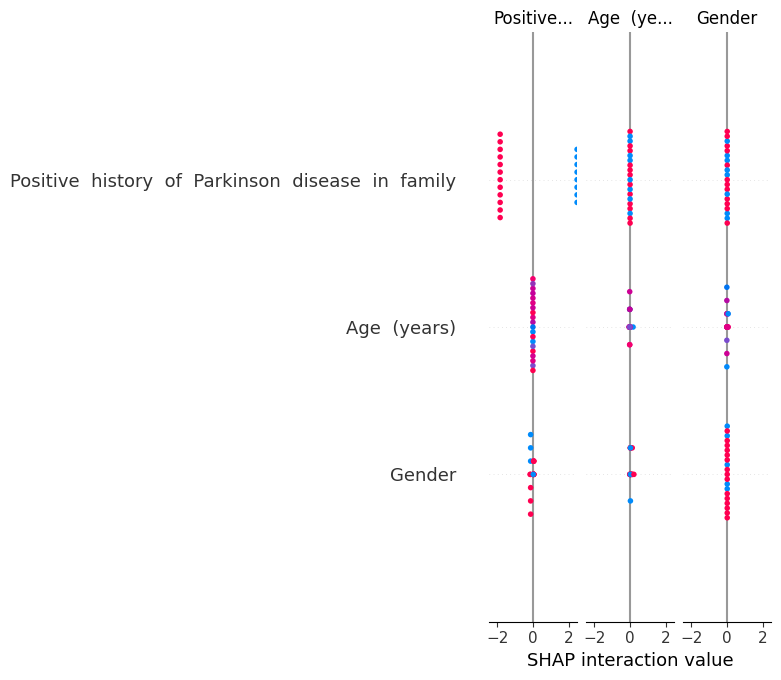

In [12]:
feature_names = list(X_train.columns)

shap.summary_plot(

    shap_values,

    X_test_xgb,

    feature_names=feature_names

)

In [13]:
joblib.dump(

    explainer,

    os.path.join(
        OUTPUT_DIR,
        "shap_explainer.pkl"
    )

)

print("SHAP explainer saved.")

SHAP explainer saved.


In [14]:
print("="*60)
print("Inference Validation")
print("="*60)

loaded_model = joblib.load(

    os.path.join(
        OUTPUT_DIR,
        "rem_ensemble.pkl"
    )

)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

probability = loaded_model.predict_proba(sample)

print("Prediction")

print(prediction)

print()

print("Probability")

print(probability)

Inference Validation
Prediction
[2]

Probability
[[0.03262893 0.01914063 0.94823046]]


In [15]:
print("="*60)
print("Artifacts")
print("="*60)

for file in sorted(os.listdir(OUTPUT_DIR)):
    print(file)

Artifacts
modality_result.json
prediction_confidence.pkl
rem_ensemble.pkl
shap_explainer.pkl
